# Steady incompressible Navier–Stokes flow around a circular obstacle

This example demonstrates how the **steady incompressible Navier–Stokes equations** can be assembled directly in LowLevelFEM using a mixed velocity–pressure formulation and Newton linearization.

The unknown fields are the velocity $\mathbf{v}$ and the pressure $p$. The equations are written for unit density, $\rho=1$:

$$
-\nu \Delta \mathbf{v}
+
(\mathbf{v}\cdot\nabla)\mathbf{v}
+
\nabla p
=
\mathbf{0},
$$

$$
\nabla\cdot\mathbf{v}=0,
$$

where $\nu$ is the viscosity coefficient in the normalized momentum equation.


In [14]:
using LowLevelFEM
using LinearAlgebra

In [15]:
openGeometry("pipe.geo")

## Mixed velocity–pressure discretization

Two independent finite element fields are introduced:

- a vector field $\mathbf{v}$ for velocity,
- a scalar field $p$ for pressure.

The pressure field uses a reduced interpolation order relative to the velocity field. This mixed approximation is required to obtain a stable discretization of the incompressibility constraint.


In [16]:
mat = Material("pipe")

P = Field([mat], type=:ScalarField, fieldName=:p, rhsName=:fp, dim=2, reducedOrder=true)
V = Field([mat], type=:VectorField, fieldName=:v, rhsName=:fv, dim=2);

## Inlet profile

A parabolic horizontal velocity profile is prescribed at the inlet:

$$
v_x(y)
=
v_{\max}
\left[
1-
\left(
\frac{y-0.5}{0.5}
\right)^2
\right],
\qquad
v_y=0.
$$

The maximum inlet velocity is $v_{\max}=10$.


In [17]:
vMax = 10.0

v_in(x, y, z) = vMax * (1.0 - ((y - 0.5) / 0.5)^2);

## Boundary conditions

The inlet velocity is prescribed on the left boundary. No-slip conditions are imposed on the upper and lower walls and on the circular obstacle:

$$
\mathbf{v}=\mathbf{0}.
$$

For incompressible flow, pressure is determined only up to an arbitrary additive constant. One pressure degree of freedom is therefore fixed by prescribing

$$
p=0
$$

on the reference boundary.


In [18]:
inlet = BoundaryCondition("left", field=V, vx=v_in, vy=0.0)
bottom = BoundaryCondition("bottom", field=V, vx=0.0, vy=0.0)
top = BoundaryCondition("top", field=V, vx=0.0, vy=0.0)
obstacle = BoundaryCondition("obstacle", field=V, vx=0.0, vy=0.0)
pref = BoundaryCondition("reference", field=P, p=0.0);

## Linear part of the weak form

For a velocity test function $\mathbf{w}$ and a pressure test function $q$, the weak form contains the viscous contribution

$$
\int_{\Omega}
\nu\,\nabla\mathbf{w}:\nabla\mathbf{v}
\,d\Omega,
$$

the pressure coupling

$$
-\int_{\Omega}
p\,\nabla\cdot\mathbf{w}
\,d\Omega,
$$

and the incompressibility constraint

$$
\int_{\Omega}
q\,\nabla\cdot\mathbf{v}
\,d\Omega=0.
$$

These linear operators are assembled once before the Newton iteration.


In [19]:
ν = 0.1

A = ∫((Grad(V) ⋅ Grad(V)) * ν; Ω="pipe")
B = ∫(Div(V) ⋅ P; Ω="pipe")
C = 0 * ∫(P ⋅ P; Ω="pipe");


## Newton linearization of the convective term

The nonlinear convective term is

$$
\mathbf{c}(\mathbf{v})
=
(\mathbf{v}\cdot\nabla)\mathbf{v}.
$$

Its directional derivative at the current iterate $\mathbf{v}^k$ is

$$
D\mathbf{c}(\mathbf{v}^k)[\delta\mathbf{v}]
=
(\mathbf{v}^k\cdot\nabla)\delta\mathbf{v}
+
(\delta\mathbf{v}\cdot\nabla)\mathbf{v}^k.
$$

The Newton system below is written **directly for the next iterate** $\mathbf{v}^{k+1}$ rather than for the increment. Therefore, the linearized convective part can be written as

$$
(\mathbf{v}^k\cdot\nabla)\mathbf{v}^{k+1}
+
(\mathbf{v}^{k+1}\cdot\nabla)\mathbf{v}^k
=
(\mathbf{v}^k\cdot\nabla)\mathbf{v}^k.
$$

The two terms on the left form the Newton tangent, while the term on the right becomes the nonlinear load contribution.


In [20]:
tol = 1e-8
maxiter = 20

vk = VectorField(V, "pipe", [0, 0, 0])
vk = projectTo2D(vk)

vnew = nothing
pnew = nothing

for k in 1:maxiter

    # ------------------------------------------------------------
    # Newton tangent: (vᵏ · ∇)v
    # ------------------------------------------------------------
    M = [
        vk[1] vk[2] 0 0
        0 0 vk[1] vk[2]
    ]

    N1 = ∫(V ⋅ M ⋅ Grad(V); Ω="pipe")

    # ------------------------------------------------------------
    # Newton tangent: (v · ∇)vᵏ
    # ------------------------------------------------------------
    J = [
        ∂x(vk[1]) ∂y(vk[1])
        ∂x(vk[2]) ∂y(vk[2])
    ]

    N2 = ∫(V ⋅ J ⋅ V; Ω="pipe")

    Av = A + N1 + N2

    # ------------------------------------------------------------
    # RHS: (vᵏ · ∇)vᵏ
    # ------------------------------------------------------------
    rx = vk[1] * ∂x(vk[1]) + vk[2] * ∂y(vk[1])
    ry = vk[1] * ∂x(vk[2]) + vk[2] * ∂y(vk[2])

    loadN = LoadCondition("pipe", field=V, fvx=rx, fvy=ry)

    fv = loadVector(V, [loadN])
    fp = loadVector(P, [])

    F = SystemVector([fv, fp])

    # ------------------------------------------------------------
    # Coupled Newton system
    # ------------------------------------------------------------
    K = SystemMatrix([
        Av -B
        -B' C
    ])

    vnew, pnew = solveField(K, F, support=[inlet, bottom, top, obstacle, pref])

    # ------------------------------------------------------------
    # Convergence
    # ------------------------------------------------------------
    vk = elementsToNodes(vk)
    err = norm(DoFs(vnew) - DoFs(vk)) / max(norm(DoFs(vnew)), eps())

    println("Newton iteration $k:  error = $err")

    vk = vnew

    err < tol && break
end

v = vnew
p = pnew;


Newton iteration 1:  error = 1.0
Newton iteration 2:  error = 0.2932357252815979
Newton iteration 3:  error = 0.0762501188048891
Newton iteration 4:  error = 0.01130085517521529
Newton iteration 5:  error = 0.0002095009412300941
Newton iteration 6:  error = 9.35851384091253e-8
Newton iteration 7:  error = 2.056326064359683e-9


## Velocity and pressure solution

After convergence, the velocity and pressure fields are sent directly to the Gmsh postprocessor.

The velocity field shows strong acceleration through the narrow passages above and below the obstacle. A symmetric low-velocity wake develops downstream of the cylinder.

The pressure field exhibits the expected build-up on the upstream side of the obstacle and a pressure drop in the wake.


In [21]:
showDoFResults(v, name="v")
showDoFResults(p, name="p");

### Velocity field

The arrows indicate the local flow direction and are colored by the velocity magnitude.

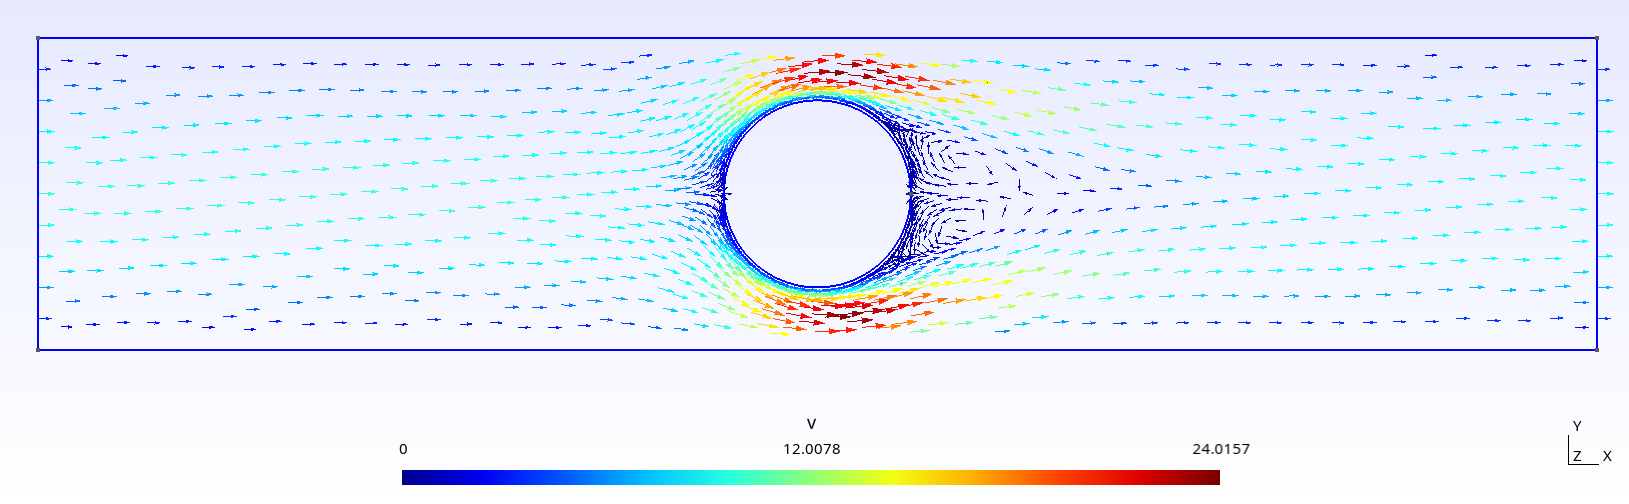


### Pressure field

The pressure field shows the characteristic pressure build-up on the upstream side of the obstacle and a lower-pressure region downstream.

Only pressure differences are physically relevant for incompressible flow. The absolute pressure level is fixed by prescribing

$$
p = 0
$$

at the reference boundary.

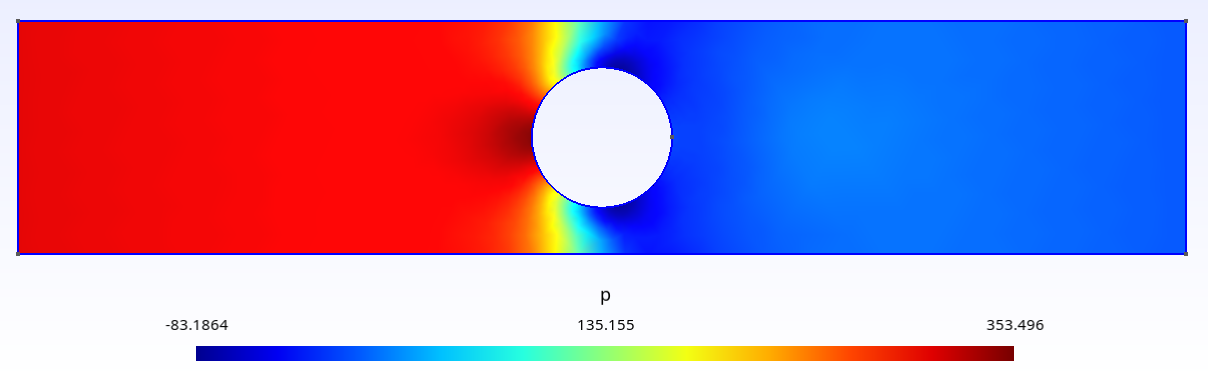

### Flow around the obstacle

A closer view reveals the strong acceleration around the cylinder and the pair of symmetric recirculation zones immediately downstream.

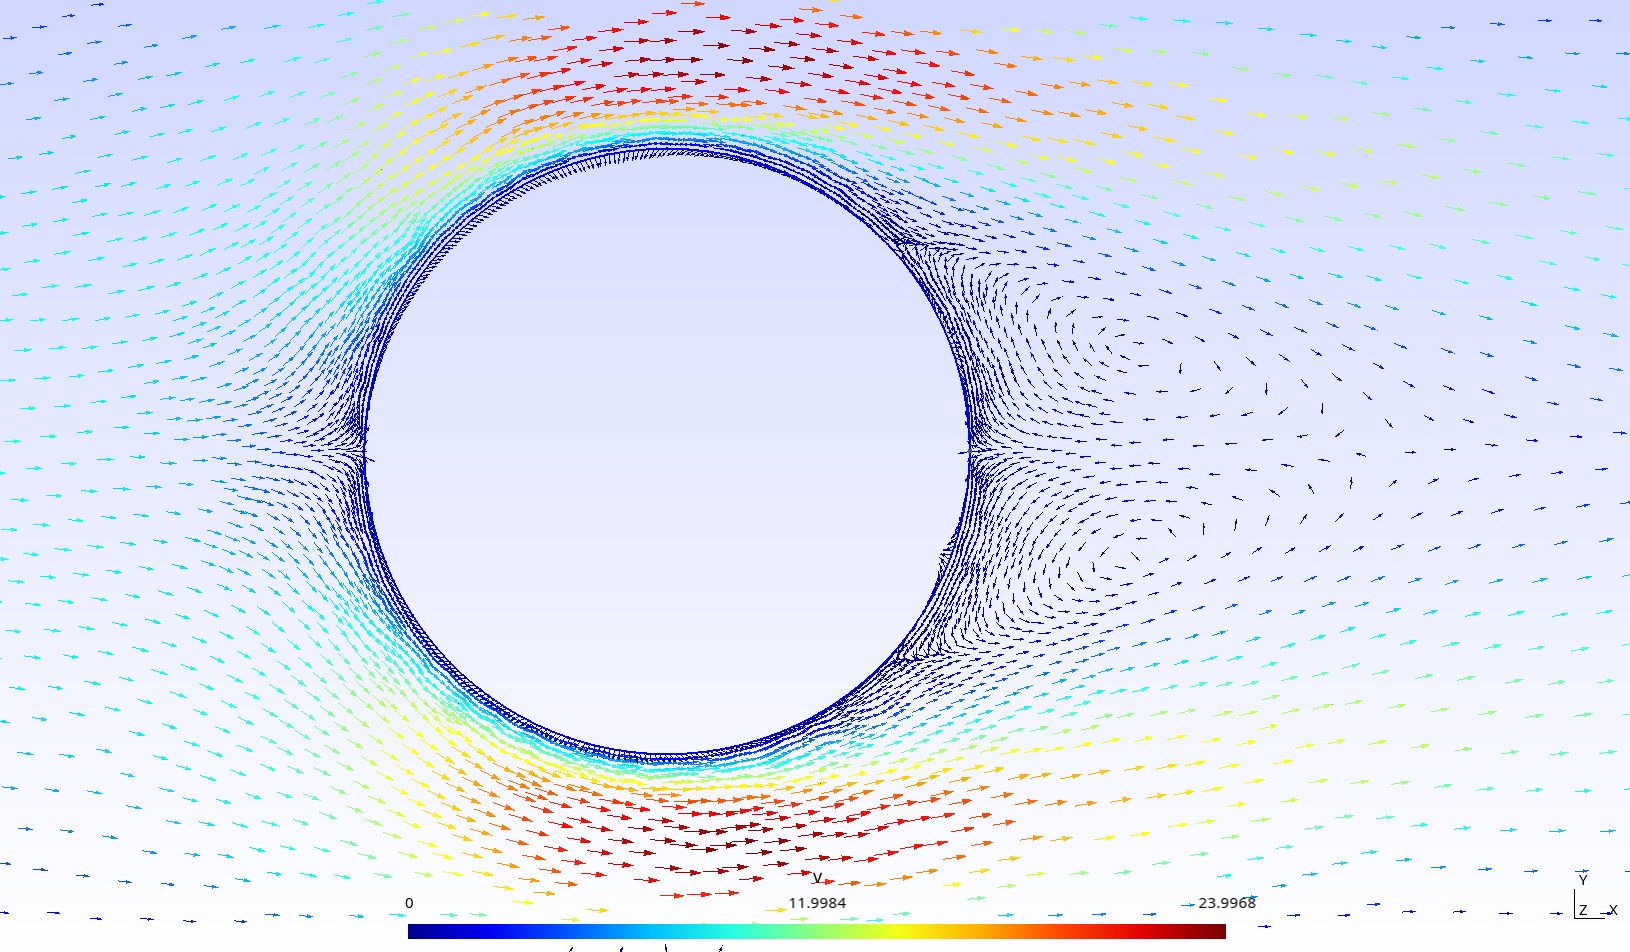


## Local divergence of the discrete velocity field

The incompressibility condition is enforced by the mixed finite element formulation in the **weak sense**:

$$
\int_{\Omega}
q\,\nabla\cdot\mathbf{v}
\,d\Omega
=
0
$$

for all pressure test functions $q$.

The field below is obtained by differentiating the discrete velocity solution pointwise:

$$
\nabla\cdot\mathbf{v}
=
\frac{\partial v_x}{\partial x}
+
\frac{\partial v_y}{\partial y}.
$$

It should therefore be interpreted as a **local post-processing measure of the discrete divergence**, not as a quantity that is constrained to vanish pointwise.


In [23]:
divv = ∂x(v[1]) + ∂y(v[2])
showDoFResults(divv, name="div(v)");

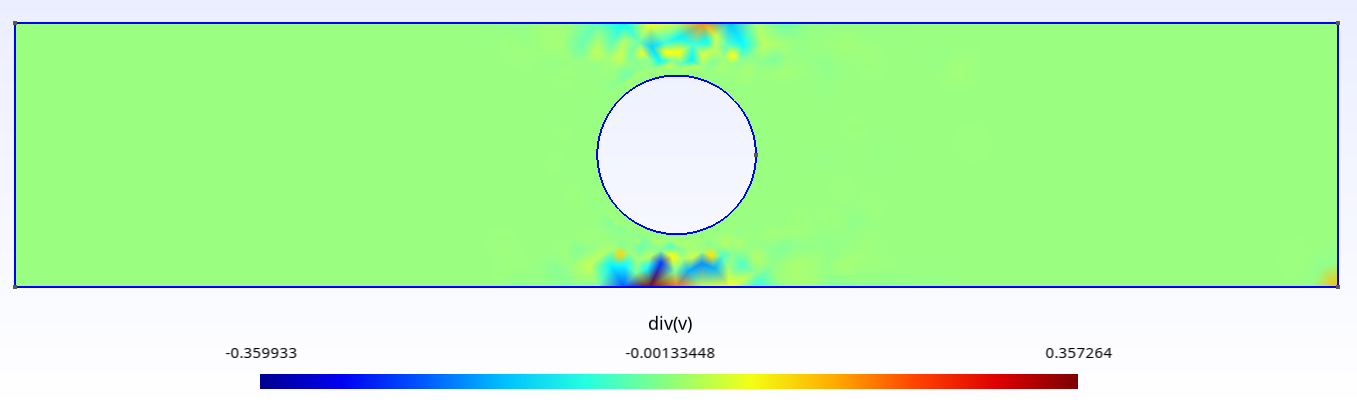

In [22]:
mean_div_v = ∫(V, "pipe", divv)

1.064274494491121e-5

### Global mass conservation

A complementary and physically intuitive check of incompressibility is the conservation of volumetric flow rate.

For a steady incompressible flow,

$$
Q_{\mathrm{in}} = Q_{\mathrm{out}},
$$

with

$$
Q =
\int_{\Gamma}
\mathbf{v}\cdot\mathbf{n}\,d\Gamma.
$$

Comparing the inlet and outlet flow rates provides a global measure of mass conservation, complementary to the local divergence plot.

In [24]:
∫(V, "left", v[1])

6.666666666666665

In [25]:
∫(V, "right", v[1])

6.666677309050623

## Takeaway

This example constructs a steady incompressible Navier–Stokes solver directly from the governing equations.

The formulation combines

- mixed velocity–pressure finite element fields,
- gradient and divergence operators,
- weak-form integration,
- Newton linearization of the nonlinear convective term,
- block sparse assembly,
- and direct finite element post-processing.

No dedicated Navier–Stokes solver is called. The nonlinear flow problem is assembled from the same field, operator, integration, and sparse-system infrastructure used elsewhere in LowLevelFEM.


In [26]:
openPostProcessor();